# The "Broken" Weather Station

Background: A mountain weather station has been offline for months and recently sent a burst of messy data. Before we can use the data and connect it to streamflow, it must be repaired and the Pandas toolkit can support this.

## Task 1: The Raw Feed 
Load the .csv of rainfall values and convert into a Pandas DataFrame named Rainfall_mm. The data can be found here:

```data/snotel_rainfall_data.csv```

Check your work: Use .head() and .describe(). Does the data look right?


## Task 2: Using Pandas Tools to make the data readable

**coerce** turns anything it can't read as a number (like 'T' or 'error') into NaN


```df['colname'] = pd.to_numeric(df['colname'], errors='coerce')```

Apply this to your dataset and then try .describe()

In [2]:
#set the column to numeric, if there is any non-numeric value, it will be set to NaN
rainfall['Precip_in'] = pd.to_numeric(rainfall['Precip_in'], errors='coerce')

#head() of the data
print(rainfall.head())
print(" ")

#summary statistics of the data
print(rainfall.describe())

         Date  Precip_in
0  2024-01-01   0.140280
1  2024-01-02   0.659018
2  2024-01-03   0.000000
3  2024-01-04   0.000000
4  2024-01-05   0.375729
 
        Precip_in
count   56.000000
mean    -8.467089
std    150.395286
min   -999.000000
25%      0.000000
50%      0.050563
75%      0.682890
max    500.000000


## Task 3: Load the discharge data

Load the .csv of rainfall values and convert into a Pandas Dataframe named streamflow_cfs. The data can be found here:

```data/streamflow_data.csv```

Check your work: Use .head() and .describe(). Does the data look right? How can you extract more useful statistics? Show this.

In [6]:
#load in data
streamflow = pd.read_csv("data/streamflow_data.csv")

#set the column to numeric, if there is any non-numeric value, it will be set to NaN
streamflow['Streamflow_cfs'] = pd.to_numeric(streamflow['Streamflow_cfs'], errors='coerce')

#head() of the data
print(streamflow.head())
print(" ")

#diescribe the data
print(streamflow.describe())

         Date  Streamflow_cfs
0  2024-01-01           10.25
1  2024-01-02           10.70
2  2024-01-03           13.30
3  2024-01-04           10.10
4  2024-01-05           10.00
 
       Streamflow_cfs
count       54.000000
mean        40.058333
std        369.096212
min       -999.000000
25%         10.100000
50%         10.600000
75%         13.900000
max       2510.000000


## Task 4: Clean and repair the data

The sensor cut out during the storm and we now have NaN **AND** -999 values. This prevents us from plotting or otherwise using the time series. Are there any other values we should remove?

Explore different methods and select one that fits the data.

Explore .dropna() (delete the gap), .fillna() with the mean, and .interpolate() for a smoother hydrograph for both datasets.

Note, it may be useful to create a new Pandas DataFrame to compare differences. 

## 4A: Clean

In [8]:
##For the Streamflow Data

#set the column to numeric, if there is any non-numeric value, it will be set to NaN
#streamflow['Streamflow_cfs'] = pd.to_numeric(streamflow['Streamflow_cfs'], errors='coerce')

#have all negative value set to NaN
streamflow.loc[streamflow['Streamflow_cfs'] < 0, 'Streamflow_cfs'] = np.nan

#have all value above 100 set to NaN
streamflow.loc[streamflow['Streamflow_cfs'] > 100, 'Streamflow_cfs'] = np.nan

#discribe the data
print(streamflow.describe())

#print the sum of all the values in the Streamflow_cfs column
print("The sum of all the values in the Streamflow_cfs column is: ", streamflow['Streamflow_cfs'].sum())

       Streamflow_cfs
count       52.000000
mean        12.541346
std          3.621988
min         10.000000
25%         10.100000
50%         10.600000
75%         13.800000
max         26.900000
The sum of all the values in the Streamflow_cfs column is:  652.15


In [9]:
##For the Precip Data

#have all negative value set to NaN
rainfall.loc[rainfall['Precip_in'] < 0, 'Precip_in'] = np.nan

#have all value above 30 set to NaN
rainfall.loc[rainfall['Precip_in'] > 30, 'Precip_in'] = np.nan

#head() of the data
print(rainfall.head())
print(" ")

#diescribe the data
print(rainfall.describe())

#print the sum of all the values in the Precip_in column
print("Total amount of precip is: ", rainfall['Precip_in'].sum())

         Date  Precip_in
0  2024-01-01   0.140280
1  2024-01-02   0.659018
2  2024-01-03   0.000000
3  2024-01-04   0.000000
4  2024-01-05   0.375729
 
       Precip_in
count  54.000000
mean    0.460056
std     0.790430
min     0.000000
25%     0.000000
50%     0.050563
75%     0.641326
max     3.609354
Total amount of precip is:  24.84300558059578


## 4B Changing NaN

In [10]:
##For the Streamflow Data

# drop NaN values but leave the number of rows the same and name new 
streamflow_dropna = streamflow_cfs.dropna()

#fill NaN values with the mean of the column
streamflow_na_mean = streamflow.fillna(streamflow['Streamflow_cfs'].mean())

# fill NaN values with interpolated values
streamflow_na_interpolate = streamflow.fillna(streamflow.interpolate(method='linear'))

#discribe the data
print ("Original data:")
print(streamflow.describe())
print("Data with NaN values dropped:")
print(streamflow_dropna.describe())
print("Data with NaN values filled with mean:")
print(streamflow_na_mean.describe())
print("Data with NaN values filled with interpolated values:")
print(streamflow_na_interpolate.describe())

Original data:
       Streamflow_cfs
count       52.000000
mean        12.541346
std          3.621988
min         10.000000
25%         10.100000
50%         10.600000
75%         13.800000
max         26.900000
Data with NaN values dropped:
              Date Streamflow_cfs
count           55             55
unique          55             37
top     2024-01-01           10.0
freq             1              8
Data with NaN values filled with mean:
       Streamflow_cfs
count       60.000000
mean        12.541346
std          3.367488
min         10.000000
25%         10.225000
50%         11.675000
75%         13.262500
max         26.900000
Data with NaN values filled with interpolated values:
       Streamflow_cfs
count       60.000000
mean        12.545417
std          3.452779
min         10.000000
25%         10.225000
50%         11.075000
75%         13.800000
max         26.900000


/scratch/local/u0972368/849839/ipykernel_857887/2219517048.py:10: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  streamflow_na_interpolate = streamflow.fillna(streamflow.interpolate(method='linear'))


In [11]:
## for the Precip Data
# drop NaN values but leave the number of rows the same and name new 
rainfall_dropna = rainfall.dropna()

#fill NaN values with the mean of the column
rainfall_na_mean = rainfall.fillna(rainfall['Precip_in'].mean())

# fill NaN values with interpolated values
rainfall_na_interpolate = rainfall.fillna(rainfall.interpolate(method='linear'))

#discribe the data
print ("Original data:")
print(rainfall.describe())
print("Data with NaN values dropped:")
print(rainfall_dropna.describe())
print("Data with NaN values filled with mean:")
print(rainfall_na_mean.describe())
print("Data with NaN values filled with interpolated values:")
print(rainfall_na_interpolate.describe())

Original data:
       Precip_in
count  54.000000
mean    0.460056
std     0.790430
min     0.000000
25%     0.000000
50%     0.050563
75%     0.641326
max     3.609354
Data with NaN values dropped:
       Precip_in
count  54.000000
mean    0.460056
std     0.790430
min     0.000000
25%     0.000000
50%     0.050563
75%     0.641326
max     3.609354
Data with NaN values filled with mean:
       Precip_in
count  61.000000
mean    0.460056
std     0.742892
min     0.000000
25%     0.000000
50%     0.168414
75%     0.532611
max     3.609354
Data with NaN values filled with interpolated values:
       Precip_in
count  61.000000
mean    0.461189
std     0.781009
min     0.000000
25%     0.000000
50%     0.093288
75%     0.659018
max     3.609354


/scratch/local/u0972368/849839/ipykernel_857887/129812260.py:9: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  rainfall_na_interpolate = rainfall.fillna(rainfall.interpolate(method='linear'))


## Task 5: Join Pandas DataFrames

We often want to relate data to another, and having all the data in once centralized data frame supports this comparison. Create a new Pandas DataFrame named:
* rainfall_methods fill it with the three rainfall dataframes we cleaned
* streamflow_methods and fill it with the three streamflow dataframes we cleaned


In [13]:
#new data fram with the 3 rainfall data frames
rainfall_combined = pd.DataFrame({
    'Precip_in': rainfall['Precip_in'],
    'Precip_in_dropna': rainfall_dropna['Precip_in'],
    'Precip_in_na_mean': rainfall_na_mean['Precip_in'],
    'Precip_in_na_interpolate': rainfall_na_interpolate['Precip_in']
})

#new data fram with the 3 streamflow data frames
streamflow_combined = pd.DataFrame({
    'Streamflow_cfs': streamflow['Streamflow_cfs'],
    'Streamflow_cfs_dropna': streamflow_dropna['Streamflow_cfs'],
    'Streamflow_cfs_na_mean': streamflow_na_mean['Streamflow_cfs'],
    'Streamflow_cfs_na_interpolate': streamflow_na_interpolate['Streamflow_cfs']
})

## Task 6: Plot the rainfall and streamflow data to visualize trends and relationships.

Use Pandas simple plotting functionality to separately plot the two dataframes. Which interpolation method do you like? 

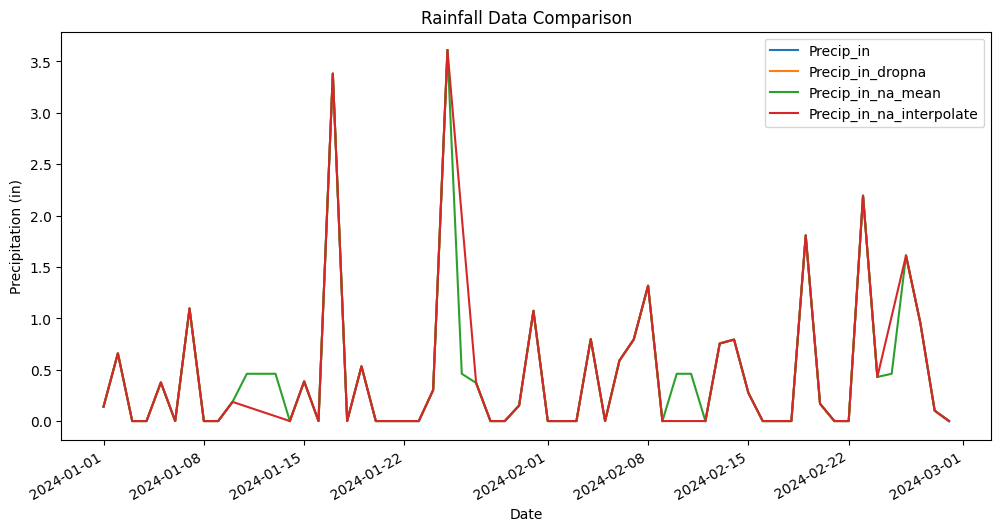

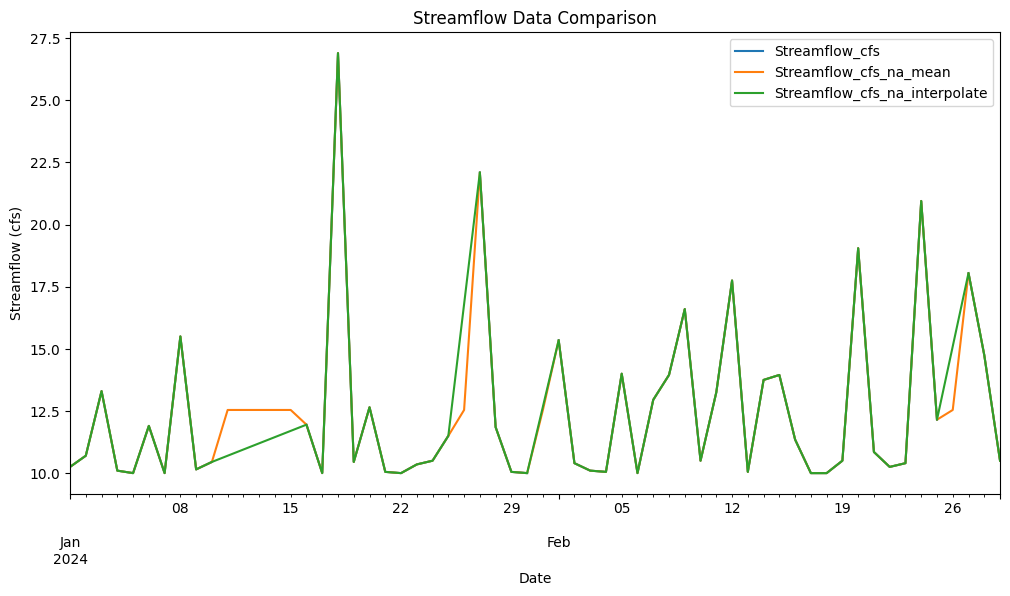

In [32]:
import matplotlib.pyplot as plt

# ensure the Date column exists in rainfall_combined and is datetime
rainfall_combined['Date'] = pd.to_datetime(rainfall['Date'])

# plot new rainfall data frame
rainfall_combined.plot(x='Date', y=['Precip_in', 'Precip_in_dropna', 'Precip_in_na_mean', 'Precip_in_na_interpolate'], figsize=(12,6))
plt.title('Rainfall Data Comparison')
plt.xlabel('Date')
plt.ylabel('Precipitation (in)')
plt.legend()
plt.show()

# ensure the Date column exists in streamflow_combined and is datetime
streamflow_combined['Date'] = pd.to_datetime(streamflow['Date'])

# plot new streamflow data frame
streamflow_combined.plot(x='Date', y=['Streamflow_cfs', 'Streamflow_cfs_dropna', 'Streamflow_cfs_na_mean', 'Streamflow_cfs_na_interpolate'], figsize=(12,6))
plt.title('Streamflow Data Comparison')
plt.xlabel('Date')
plt.ylabel('Streamflow (cfs)')
plt.legend()
plt.show()

## Task 7: Combining DataFrames

From the plots above, choose your most representative gap filling dataframe for rainfall and streamflow, and combine them into a rain_flow_df DataFrame.

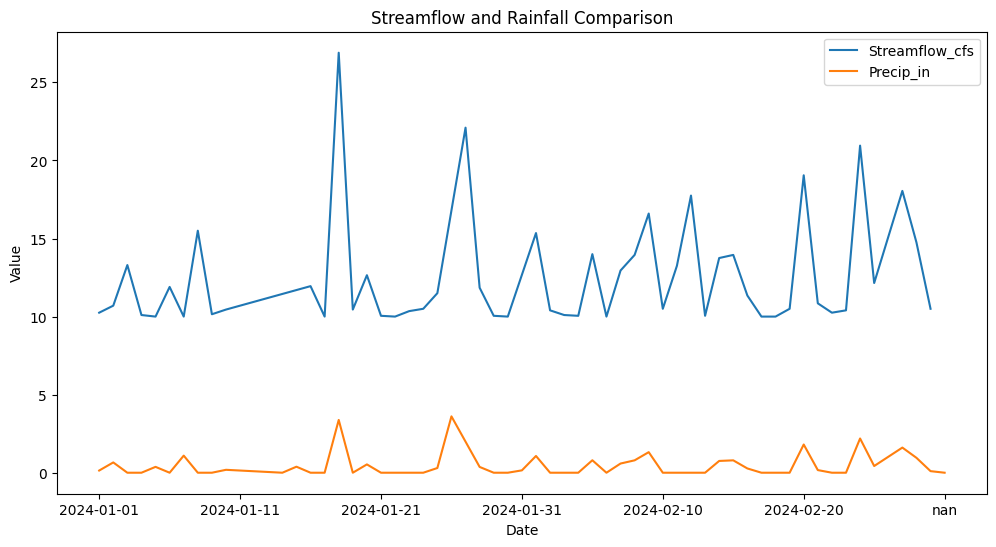

In [33]:
#create best data frame from interpolated data from streamflow and rainfall

rain_flow_df = pd.DataFrame({
    'Date': streamflow['Date'],
    'Streamflow_cfs': streamflow_na_interpolate['Streamflow_cfs'],
    'Precip_in': rainfall_na_interpolate['Precip_in']
})

#plot it
rain_flow_df.plot(x='Date', y=['Streamflow_cfs', 'Precip_in'], figsize=(12,6))
plt.title('Streamflow and Rainfall Comparison')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

## Task 8: Calculate the monthly statistics of the rainfall and discharge

Calculate the monthly total, mean daily (for each month), and the maximum (for each month) rainfall and flow. 

In [34]:
#monthly total of streamflow and rainfall
rain_flow_df['Date'] = pd.to_datetime(rain_flow_df['Date'])
rain_flow_df.set_index('Date', inplace=True)
monthly_totals = rain_flow_df.resample('M').sum()
print("Monthly totals:")
print(monthly_totals)
print(" ")

#monthly average of streamflow and rainfall
monthly_averages = rain_flow_df.resample('M').mean()
print("Monthly averages:")
print(monthly_averages)
print(" ")

#monthly max of streamflow and rainfall
monthly_max = rain_flow_df.resample('M').max()
print("Monthly max:")
print(monthly_max)

Monthly totals:
            Streamflow_cfs  Precip_in
Date                                 
2024-01-31         376.175  13.459045
2024-02-29         376.550  14.673510
 
Monthly averages:
            Streamflow_cfs  Precip_in
Date                                 
2024-01-31       12.134677   0.434163
2024-02-29       12.984483   0.505983
 
Monthly max:
            Streamflow_cfs  Precip_in
Date                                 
2024-01-31           26.90   3.609354
2024-02-29           20.95   2.193069


/scratch/local/u0972368/849839/ipykernel_857887/142788957.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_totals = rain_flow_df.resample('M').sum()
/scratch/local/u0972368/849839/ipykernel_857887/142788957.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_averages = rain_flow_df.resample('M').mean()
/scratch/local/u0972368/849839/ipykernel_857887/142788957.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_max = rain_flow_df.resample('M').max()


## Task 9: Data Corrections

We want to put the data into a streamflow model, but it requires precipitation to be in mm and streamflow to be in CMS (cubic meters per second). Create a new dataframe called rain_flow_SI_df that converts the previous dataframe to SI units.

In [36]:
# SI dataframe
# change rain_flow_df to SI units
# If 'Date' was previously set as the index, restore it to a column first
if 'Date' not in rain_flow_df.columns and isinstance(rain_flow_df.index, pd.DatetimeIndex):
    rain_flow_df = rain_flow_df.reset_index().rename(columns={rain_flow_df.index.name or 'index': 'Date'})

# Ensure Date column is datetime
rain_flow_df['Date'] = pd.to_datetime(rain_flow_df['Date'])

rain_flow_df_SI = pd.DataFrame({
    'Date': rain_flow_df['Date'],
    'Streamflow_m3s': rain_flow_df['Streamflow_cfs'] * 0.0283168, # convert cfs to m3/s
    'Precip_mm': rain_flow_df['Precip_in'] * 25.4 # convert inches to mm
})

# monthly total of streamflow and rainfall
rain_flow_df_SI.set_index('Date', inplace=True)
monthly_totals = rain_flow_df_SI.resample('M').sum()
print("Monthly totals:")
print(monthly_totals)
print(" ")

# monthly average of streamflow and rainfall
monthly_averages = rain_flow_df_SI.resample('M').mean()
print("Monthly averages:")
print(monthly_averages)
print(" ")

# monthly max of streamflow and rainfall
monthly_max = rain_flow_df_SI.resample('M').max()
print("Monthly max:")
print(monthly_max)

Monthly totals:
            Streamflow_m3s   Precip_mm
Date                                  
2024-01-31       10.652072  341.859741
2024-02-29       10.662691  372.707142
 
Monthly averages:
            Streamflow_m3s  Precip_mm
Date                                 
2024-01-31        0.343615  11.027734
2024-02-29        0.367679  12.851970
 
Monthly max:
            Streamflow_m3s  Precip_mm
Date                                 
2024-01-31        0.761722  91.677590
2024-02-29        0.593237  55.703955


/scratch/local/u0972368/849839/ipykernel_857887/799193106.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_totals = rain_flow_df_SI.resample('M').sum()
/scratch/local/u0972368/849839/ipykernel_857887/799193106.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_averages = rain_flow_df_SI.resample('M').mean()
/scratch/local/u0972368/849839/ipykernel_857887/799193106.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_max = rain_flow_df_SI.resample('M').max()


## Task 10: Event diagnostics

A key element of hydroinformatics is to identify key events and learn from them. Here, we have two tasks.
* Create a new column and programatically label each day as 'Dry', 'Light Rain', or 'Heavy Rain' based on the precipitaiton column.
* From our rain_flow_SI_df, create a new Pandas DataFrame called storm_df that programatically selects the streamflow and precipitation data for 5 days before and after the peak flow event.

Task 1: Weather Column

In [39]:
# add new column called "weather"
def label_weather(mm):
    if pd.isna(mm):
        return 'No Data'
    if mm < 1:
        return 'Dry'
    elif mm < 20:
        return 'Light Rain'
    else:
        return 'Heavy Rain'

rain_flow_df_SI['weather'] = rain_flow_df_SI['Precip_mm'].apply(label_weather)
print(rain_flow_df_SI[['Precip_mm', 'weather']].head())

            Precip_mm     weather
Date                             
2024-01-01   3.563120  Light Rain
2024-01-02  16.739058  Light Rain
2024-01-03   0.000000         Dry
2024-01-04   0.000000         Dry
2024-01-05   9.543520  Light Rain


Task 2: Storm DF

In [40]:
# Identify peak flow event and extract 5 days before and after
# Ensure the index is a DatetimeIndex
if not isinstance(rain_flow_df_SI.index, pd.DatetimeIndex):
    rain_flow_df_SI.index = pd.to_datetime(rain_flow_df_SI.index)

# locate peak flow time
peak_time = rain_flow_df_SI['Streamflow_m3s'].idxmax()
start = peak_time - pd.Timedelta(days=5)
end = peak_time + pd.Timedelta(days=5)

# slice the window and keep relevant columns
storm_df = rain_flow_df_SI.loc[start:end, ['Streamflow_m3s', 'Precip_mm', 'weather']].copy()

print('Peak flow at', peak_time)
print(storm_df)

Peak flow at 2024-01-18 00:00:00
            Streamflow_m3s  Precip_mm     weather
Date                                             
2024-01-13        0.317148   1.184761  Light Rain
2024-01-14        0.324227   0.000000         Dry
2024-01-15        0.331307   9.798213  Light Rain
2024-01-16        0.338386   0.000000         Dry
2024-01-17        0.283168   0.000000         Dry
2024-01-18        0.761722  85.876653  Heavy Rain
2024-01-19        0.295911   0.000000         Dry
2024-01-20        0.358208  13.528311  Light Rain
2024-01-21        0.284584   0.000000         Dry
2024-01-22        0.283168   0.000000         Dry
2024-01-23        0.293079   0.000000         Dry


## Task 11: Quick Data Visualziation

Use the pandas plot function to conduct a quick visualization of precipitation and streamflow. Do they seem coorelated? Any glaring errors?

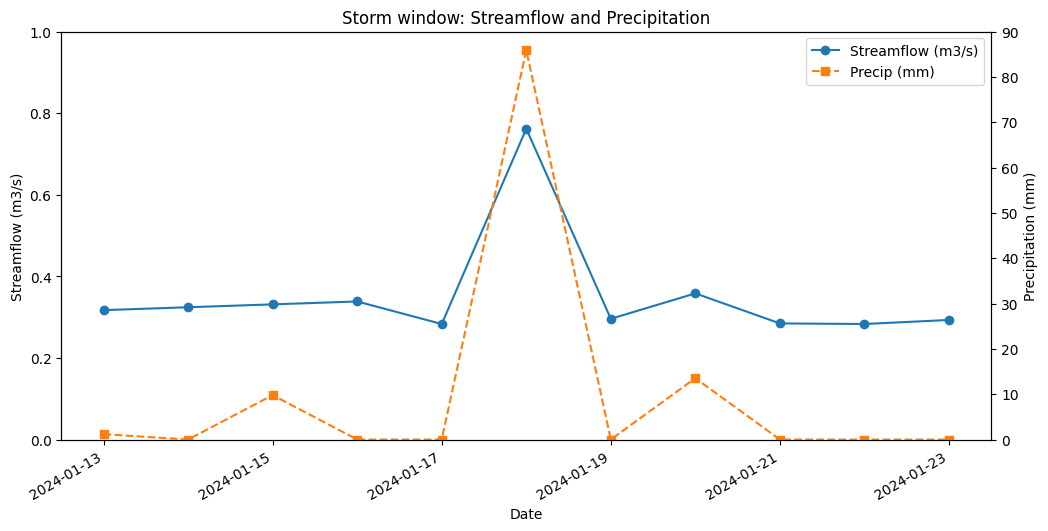

In [49]:
# Plot storm_df as two lines with separate y-scales and a single x-axis
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12,6))
# streamflow as line on left axis
ax.plot(storm_df.index, storm_df['Streamflow_m3s'], color='C0', marker='o', label='Streamflow (m3/s)')
ax.set_ylabel('Streamflow (m3/s)')
ax.set_ylim(0, 1)

# precipitation as line on right axis
ax2 = ax.twinx()
ax2.plot(storm_df.index, storm_df['Precip_mm'], color='C1', marker='s', linestyle='--', label='Precip (mm)')
ax2.set_ylabel('Precipitation (mm)')
ax2.set_ylim(0, 90)

# format shared x-axis (dates) and rotate labels once
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate()

# combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines+lines2, labels+labels2, loc='best')
plt.title('Storm window: Streamflow and Precipitation')
plt.show()